In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Tue Mar 25 11:44:03 2025

@author: t778b526
"""

# Setup code - run first

import matplotlib.pyplot as plt
import GPy
import numpy as np
from numpy.random import seed
seed(12345)
from emukit.core import ParameterSpace, ContinuousParameter
from emukit.model_wrappers.gpy_model_wrappers import GPyModelWrapper
from emukit.bayesian_optimization.loops import BayesianOptimizationLoop
from emukit.core.loop import LoopState # Needed for getting current evaluation
from emukit.core.loop import FixedIterationsStoppingCondition
# from emukit.core.loop import ConvergenceStoppingCondition # THIS IS BASED ON X DISTANCES, NOT Y DISTANCES
from emukit.core.loop import StoppingCondition
# from decimal import Decimal, ROUND_HALF_UP # Good for rounding number with more control than round()
# from IPython.display import display

# from scipy.signal import find_peaks
from scipy.stats import qmc
# import itertools
import csv
# from IPython import display
from scipy.integrate import odeint
# from simple_pid import PID
# import datetime
import control as ctl
import math

# Not sure what this does, but need it to access log like other conditions do
import logging
_log = logging.getLogger(__name__)


def plot_convergence(X, Y):
    '''
    Plots the convergence of standard Bayesian optimization algorithms.

    :param X: Locations of evaluated points
    :param Y: Results of evaluations

    '''
    n = X.shape[0]

    ## Distances between consecutive x's
    aux = (X[1:n,:] - X[0:n-1,:])**2
    distances = np.sqrt(aux.sum(axis=1))

    plt.figure(figsize=(10,5))
    plt.subplot(1, 2, 1)
    plt.plot(list(range(n-1)), distances, '-ro')
    plt.xlabel('Iteration')
    plt.ylabel('d(x[n], x[n-1])')
    plt.title('Distance between consecutive x\'s')

    # Best found value at each iteration
    best_Y = np.minimum.accumulate(Y)

    plt.subplot(1, 2, 2)
    plt.plot(list(range(n)), best_Y, '-o')
    plt.title('Value of the best selected sample')
    plt.xlabel('Iteration')
    plt.ylabel('Best y')
    
def plot_acquisition(emukit_bo_loop: BayesianOptimizationLoop, space: ParameterSpace,
                     label_x: str=None, label_y: str=None):
    """
    Plots the model and the acquisition function.
        if self.input_dim = 1: Plots data, mean and variance in one plot and the acquisition function in another plot
        if self.input_dim = 2: as before but it separates the mean and variance of the model in two different plots
    :param label_x: Graph's x-axis label, if None it is renamed to 'x' (1D) or 'X1' (2D)
    :param label_y: Graph's y-axis label, if None it is renamed to 'f(x)' (1D) or 'X2' (2D)
    """
    return _plot_acquisition(space.get_bounds(),
                            emukit_bo_loop.loop_state.X.shape[1],
                            emukit_bo_loop.model,
                            emukit_bo_loop.model.X,
                            emukit_bo_loop.model.Y,
                            emukit_bo_loop.candidate_point_calculator.acquisition,
                            emukit_bo_loop.get_next_points(None),
                            label_x,
                            label_y)

def _plot_acquisition(bounds, input_dim, model, Xdata, Ydata, acquisition_function, suggested_sample,
                     label_x=None, label_y=None, color_by_step=True):
    '''
    Plots of the model and the acquisition function in 1D and 2D examples.
    '''

    if input_dim ==1:
        # Plots for 1D input
        if not label_x:
            label_x = 'x'

        if not label_y:
            label_y = 'f(x)'

        x_grid = np.arange(bounds[0][0], bounds[0][1], 0.001)
        x_grid = x_grid.reshape(len(x_grid),1)
        acq = acquisition_function.evaluate(x_grid)
        acq_normalized = (acq - min(acq))/(max(acq) - min(acq))
        m, v = model.predict(x_grid)

        upper_conf_bound = m[:, 0] + 1.96 * np.sqrt(v)[:, 0]
        lower_conf_bound = m[:, 0] - 1.96 * np.sqrt(v)[:, 0]

        plt.figure()
        plt.fill_between(x_grid[:, 0], upper_conf_bound, lower_conf_bound, color='b', alpha=0.2)
        plt.plot(x_grid, lower_conf_bound, 'k-', alpha=0.2)
        plt.plot(x_grid, upper_conf_bound, 'k-', alpha=0.2)
        plt.plot(x_grid, m, 'k-', lw=1, alpha=0.6)

        plt.plot(Xdata, Ydata, 'r.', markersize=10)
        plt.axvline(x=suggested_sample[len(suggested_sample)-1], color='r')
        factor = max(upper_conf_bound) - min(lower_conf_bound)

        plt.plot(x_grid, 0.2*factor*acq_normalized - abs(min(lower_conf_bound)) - 0.25*factor, 'r-',
                 lw=2, label='Acquisition')
        plt.xlabel(label_x)
        plt.ylabel(label_y)
        plt.ylim(min(lower_conf_bound) - 0.25*factor,  max(upper_conf_bound) + 0.05*factor)
        plt.axvline(x=suggested_sample[len(suggested_sample)-1],color='r')
        plt.legend(loc='upper left')

    elif input_dim == 2:

        if not label_x:
            label_x = 'X1'

        if not label_y:
            label_y = 'X2'

        n = Xdata.shape[0]
        colors = np.linspace(0, 1, n)
        cmap = plt.cm.Reds
        norm = plt.Normalize(vmin=0, vmax=1)
        points_var_color = lambda X: plt.scatter(
            X[:,0], X[:,1], c=colors, label=u'Observations', cmap=cmap, norm=norm)
        points_one_color = lambda X: plt.plot(
            X[:,0], X[:,1], 'r.', markersize=10, label=u'Observations')
        X1 = np.linspace(bounds[0][0], bounds[0][1], 200)
        X2 = np.linspace(bounds[1][0], bounds[1][1], 200)
        x1, x2 = np.meshgrid(X1, X2)
        X = np.hstack((x1.reshape(200*200,1),x2.reshape(200*200,1)))
        acq = acquisition_function.evaluate(X)
        acq_normalized = (acq - min(acq))/(max(acq) - min(acq))
        acq_normalized = acq_normalized.reshape((200,200))
        m, v = model.predict(X)
        plt.figure(figsize=(15,5))
        plt.subplot(1, 3, 1)
        plt.contourf(X1, X2, m.reshape(200,200),100)
        plt.colorbar()
        if color_by_step:
            points_var_color(Xdata)
        else:
            points_one_color(Xdata)
        plt.ylabel(label_y)
        plt.title('Posterior mean')
        plt.axis((bounds[0][0],bounds[0][1],bounds[1][0],bounds[1][1]))
        ##
        plt.subplot(1, 3, 2)
        plt.contourf(X1, X2, np.sqrt(v.reshape(200,200)),100)
        plt.colorbar()
        if color_by_step:
            points_var_color(Xdata)
        else:
            points_one_color(Xdata)
        plt.xlabel(label_x)
        plt.ylabel(label_y)
        plt.title('Posterior sd.')
        plt.axis((bounds[0][0],bounds[0][1],bounds[1][0],bounds[1][1]))
        ##
        plt.subplot(1, 3, 3)
        plt.contourf(X1, X2, acq_normalized,100)
        plt.colorbar()
        plt.plot(suggested_sample[:,0],suggested_sample[:,1],'m.', markersize=10)
        plt.xlabel(label_x)
        plt.ylabel(label_y)
        plt.title('Acquisition function')
        plt.axis((bounds[0][0],bounds[0][1],bounds[1][0],bounds[1][1]))

    else:
        raise ValueError(f'Cannot plot inputs higher than 2D, {input_dim} given')

class xy_distance(StoppingCondition):
    """Stops once we choose a point within eps of a previous point
    (with respect to euclidean norm) AND within another eps for the
    y value. Close evaluations can suggest convergence of the
    optimization for problems with low observation noise.
    """

    def __init__(self, eps_x: float, eps_y: float, patience=0) -> None:
        """
        :param eps: minimum distance between
        two consecutive x's to keep running the model
        """
        self.eps_x = eps_x
        self.eps_y = eps_y
        self.patience = patience
        self.consecutive_stops = 0

    def should_stop(self, loop_state: LoopState) -> bool:
        """
        :param loop_state: Object that contains current state of the loop
        :return: True if the euclidean distance between the last two evaluations
                    is smaller than the specified eps.
        """
        if loop_state.iteration < 2:
            # less than 2 evaluations so cannot calculate distance
            return False
        distance_x = np.linalg.norm(loop_state.X[-1, :] - loop_state.X[-2, :]).item()
        distance_y = np.linalg.norm(loop_state.Y[-1, :] - loop_state.Y[-2, :]).item() # Same as previous
        
        # Print for testing purposes - not necessary for performance
#         print("\ndistance_x:", distance_x)
#         print("distance_y:", distance_y)
#         print("consecutive stops:", self.consecutive_stops)
        
        if distance_x <= self.eps_x and distance_y <= self.eps_y: # Need both to be true to increment
            # If the distance is within the tolerance, increment the counter
            self.consecutive_stops += 1
        else:
            # Reset the counter if the distance is above eps
            self.consecutive_stops = 0
        
        # Check if the patience tolerance has been reached
        if self.consecutive_stops >= self.patience:
            # Printing for testing purposes, not for performance. Logging is to follow format from source code.
            print("Stopped as consecutive X evaluations are within {}".format(self.eps_x) + \
                  " and consecutive Y evaluations are within {}".format(self.eps_y) + \
                  " for {}".format(self.patience) + " iterations.")
            _log.info("Stopped as consecutive X evaluations are within {}".format(self.eps_x) + " and consecutive Y evaluations are within {}".format(self.eps_y) + " for {}".format(self.patience) + " iterations.")
            return True
        
        return False


# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.signal import find_peaks
# import itertools
# # import csv
# from IPython import display
# from scipy.integrate import odeint
# import time

import time
import warnings
from collections import deque


def _clamp(value, limits):
    lower, upper = limits
    if value is None:
        return None
    elif upper is not None and value > upper:
        return upper
    elif lower is not None and value < lower:
        return lower
    return value

try:
    # get monotonic time to ensure that time deltas are always positive
    _current_time = time.monotonic
except AttributeError:
    # time.monotonic() not available (using python < 3.3), fallback to time.time()
    _current_time = time.time
    warnings.warn('time.monotonic() not available in python < 3.3, using time.time() as fallback')


class PID(object):
    """
    A simple PID controller. No fuss.
    """

    def __init__(self,
                 Kp=1.0, Ki=0.0, Kd=0.0,
                 setpoint=0,
                 sample_time=0.01,
                 meas_int=1,
                 output_limits=(None, None),
                 auto_mode=True,
                 proportional_on_measurement=False,
                 integral_timescale=0):
        """
        :param Kp: The value for the proportional gain Kp
        :param Ki: The value for the integral gain Ki
        :param Kd: The value for the derivative gain Kd
        :param setpoint: The initial setpoint that the PID will try to achieve
        :param sample_time: The time in seconds which the controller should wait before generating a new output value.
                            The PID works best when it is constantly called (eg. during a loop), but with a sample
                            time set so that the time difference between each update is (close to) constant. If set to
                            None, the PID will compute a new output value every time it is called.
        :param output_limits: The initial output limits to use, given as an iterable with 2 elements, for example:
                              (lower, upper). The output will never go below the lower limit or above the upper limit.
                              Either of the limits can also be set to None to have no limit in that direction. Setting
                              output limits also avoids integral windup, since the integral term will never be allowed
                              to grow outside of the limits.
        :param auto_mode: Whether the controller should be enabled (in auto mode) or not (in manual mode)
        :param proportional_on_measurement: Whether the proportional term should be calculated on the input directly
                                            rather than on the error (which is the traditional way). Using
                                            proportional-on-measurement avoids overshoot for some types of systems.
        """
        self.Kp, self.Ki, self.Kd = Kp, Ki, Kd
        self.setpoint = setpoint
        self.sample_time = sample_time

        self._min_output, self._max_output = output_limits
        self._auto_mode = auto_mode
        self.proportional_on_measurement = proportional_on_measurement
        
        self.integral_timescale = integral_timescale # Do in hours
        self.meas_int = meas_int # This will be in seconds
        
        # Declare list that will maintain a set timeframe of error terms to sum
        self.integral_terms = deque(maxlen=round(self.integral_timescale*60*60/self.meas_int))

        self.reset()

    def __call__(self, input_, dt=None):
        """
        Call the PID controller with *input_* and calculate and return a control output if sample_time seconds has
        passed since the last update. If no new output is calculated, return the previous output instead (or None if
        no value has been calculated yet).
        :param dt: If set, uses this value for timestep instead of real time. This can be used in simulations when
                   simulation time is different from real time.
        """
        if not self.auto_mode:
            return self._last_output

        now = _current_time()
        if dt is None:
            dt = now - self._last_time if now - self._last_time else 1e-16
        elif dt <= 0:
            raise ValueError("dt has nonpositive value {}. Must be positive.".format(dt))

        if self.sample_time is not None and dt < self.sample_time and self._last_output is not None:
            # only update every sample_time seconds
            return self._last_output

        # compute error terms
        error = self.setpoint - input_
        d_input = input_ - (self._last_input if self._last_input is not None else input_)

        # compute the proportional term
        if not self.proportional_on_measurement:
            # regular proportional-on-error, simply set the proportional term
            self._proportional = self.Kp * error
        else:
            # add the proportional error on measurement to error_sum
            self._proportional -= self.Kp * d_input

        # compute integral and derivative terms
        if self.integral_timescale == 0:
            self._integral += self.Ki * error * dt
            self._integral = _clamp(self._integral, self.output_limits)  # avoid integral windup
        # if interested in using a set timeframe for error integral, use this
        else:
            self.integral_terms.append(self.Ki * error * dt) # deque automatically discards oldest element when full
            self._integral = sum(self.integral_terms)
            self._integral = _clamp(self._integral, self.output_limits)  # avoid integral windup            

        self._derivative = -self.Kd * d_input / dt

        # compute final output
        output = self._proportional + self._integral + self._derivative
        output = _clamp(output, self.output_limits)

        # keep track of state
        self._last_output = output
        self._last_input = input_
        self._last_time = now

        return output

    @property
    def components(self):
        """
        The P-, I- and D-terms from the last computation as separate components as a tuple. Useful for visualizing
        what the controller is doing or when tuning hard-to-tune systems.
        """
        return self._proportional, self._integral, self._derivative

    @property
    def tunings(self):
        """The tunings used by the controller as a tuple: (Kp, Ki, Kd)"""
        return self.Kp, self.Ki, self.Kd

    @tunings.setter
    def tunings(self, tunings):
        """Setter for the PID tunings"""
        self.Kp, self.Ki, self.Kd = tunings

    @property
    def auto_mode(self):
        """Whether the controller is currently enabled (in auto mode) or not"""
        return self._auto_mode

    @auto_mode.setter
    def auto_mode(self, enabled):
        """Enable or disable the PID controller"""
        self.set_auto_mode(enabled)

    def set_auto_mode(self, enabled, last_output=None):
        """
        Enable or disable the PID controller, optionally setting the last output value.
        This is useful if some system has been manually controlled and if the PID should take over.
        In that case, pass the last output variable (the control variable) and it will be set as the starting
        I-term when the PID is set to auto mode.
        :param enabled: Whether auto mode should be enabled, True or False
        :param last_output: The last output, or the control variable, that the PID should start from
                            when going from manual mode to auto mode
        """
        if enabled and not self._auto_mode:
            # switching from manual mode to auto, reset
            self.reset()

            self._integral = (last_output if last_output is not None else 0)
            self._integral = _clamp(self._integral, self.output_limits)

        self._auto_mode = enabled

    @property
    def output_limits(self):
        """
        The current output limits as a 2-tuple: (lower, upper). See also the *output_limts* parameter in
        :meth:`PID.__init__`.
        """
        return self._min_output, self._max_output

    @output_limits.setter
    def output_limits(self, limits):
        """Setter for the output limits"""
        if limits is None:
            self._min_output, self._max_output = None, None
            return

        min_output, max_output = limits

        if None not in limits and max_output < min_output:
            raise ValueError('lower limit must be less than upper limit')

        self._min_output = min_output
        self._max_output = max_output

        self._integral = _clamp(self._integral, self.output_limits)
        self._last_output = _clamp(self._last_output, self.output_limits)

    def reset(self):
        """
        Reset the PID controller internals, setting each term to 0 as well as cleaning the integral,
        the last output and the last input (derivative calculation).
        """
        self._proportional = 0
        self._integral = 0
        self._derivative = 0

        self._last_time = _current_time()
        self._last_output = None
        self._last_input = None

# define two tank system model
def two_tanks(x,t,ut,Cait,Ft,Cact,Ftott,Vt):

    # States (3):
    # Flowrate of correction stream (m3/min)
    Fc = x[0]
    # Conc. of tank 1 outlet (kg/m3)
    Ca1 = x[1]
    # Conc. of tank 2 outlet (kg/m3)
    Ca2 = x[2]

    # Parameters:
    # Kv - Valve gain (m3/(min*controller_out_units))
    Kv = 0.01
    
    # tauV - Valve constant (min)
    tauV = 0.1
    
    # Calculate valve derivative
    dFcdt = (Kv/tauV)*ut - (1/tauV)*Fc
    
    # Calculate concentration in tank 1 derivative
    dCa1dt = (Ft/Vt[0])*Cait + (Cact/Vt[0])*Fc - (Ftott/Vt[0])*Ca1
    
    # Calculate Concentration in tank 2 derivative
    dCa2dt = (Ftott/Vt[1])*Ca1 - (Ftott/Vt[1])*Ca2
    
    # Return xdot:
    xdot = np.zeros(3)
    xdot[0] = dFcdt
    xdot[1] = dCa1dt
    xdot[2] = dCa2dt
    return xdot

# define two tank system model
def two_tanks_lin(Cai_ttl,F_ttl,Cac_ttl,Fc_ttl,Ca1_ttl,Ca2_ttl,V_ttl):
    # Parameters:
    # Kv - Valve gain (m3/(min*controller_out_units))
    Kv = 0.01
    
    # tauV - Valve constant (min)
    tauv = 0.1
    
    # Total flowrate
    Ftott = F_ttl + Fc_ttl
    
    A = [[-1/tauv, 0, 0],
        [(Cac_ttl - Ca1_ttl)/V_ttl[0], -Ftott/V_ttl[0], 0],
        [0, Ftott/V_ttl[1], -Ftott/V_ttl[1]]]
    
    B = [Kv/tauv, 0, 0]
    
    C = [0, 0, 1]
    
    D = [0]

    tt_lin = ctl.StateSpace(A, B, C, D)
    
    # Return syste,:
    return tt_lin

def get_sys(Cai_sys, F_sys, Cac_sys, Fc_sys, V_sys:list):
    print('Cai:', Cai_sys, '  F:', F_sys, '  Cac:', Cac_sys, '  Fc_sys:', Fc_sys)
    Ftot = F_sys + Fc_sys
    Ca1_ss_sys = Ca2_ss_sys = (F_sys * Cai_sys + Fc_sys * Cac_sys) / Ftot
    
    sys = two_tanks_lin(Cai_sys,F_sys,Cac_sys,Fc_sys,Ca1_ss_sys,Ca2_ss_sys,V_sys)

    zeros = ctl.zeros(sys)
    poles = ctl.poles(sys)

    tcz = 1/abs(zeros.real)
    tcp = 1/abs(poles.real)
    
    print('zeros:', zeros)
    print('poles:', poles)
    print('tcz:', tcz)
    print('tcp:', tcp)

    tcp.sort()
    
    print('sorted tcp:', tcp)

    tau1 = tcp[-1]
    tau2 = tcp[-2] + tcp[-3]/2

    gain = ctl.dcgain(sys) # * abs(poles.real) / abs(zeros.real)
    print('gain:', gain)
    
    theta = tcp[-3]/2 - sum(tcz)
    for ctr in range(len(tcp)-3):
        theta += tcp[ctr]
    theta_check = tcp[-3]/2 - sum(tcz)
    print('theta:', theta)
    print('theta_check:', theta_check)
    
    print('tau1:', tau1)
    print('tau2:', tau2)
    
    taus = np.sqrt(tau1*tau2)
    if abs(0.5*taus) > abs(4*theta):
        tauc = 0.5*taus
    else:
        tauc = 4*theta
    tauc = max(abs(0.1*taus), abs(0.8*theta))
    Kci = (1/gain)*((tau1+tau2)/(theta+tauc))
    Kii = Kci / (tau1 + tau2) # tauI = tau1 + tau2
    Kdi = Kci * (tau1*tau2/(tau1+tau2)) # tauD = tau1*tau2/(tau1+tau2)
    
    print('PID parameters:', Kci, Kii, Kdi, "\n\n\n")
    
    global kc_oom, ki_oom, kd_oom, Ca1_ss_global, Ca2_ss_global, Cai_global, F_global, Cac_global, Fc_global
    kc_oom = oom(Kci)
    ki_oom = oom(Kii)
    kd_oom = oom(Kdi)
    Ca1_ss_global = Ca1_ss_sys
    Ca2_ss_global = Ca2_ss_sys
    Cai_global = Cai_sys
    F_global = F_sys
    Cac_global = Cac_sys
    Fc_global = Fc_sys
    
    print("Global variables upon declaration:")
    print("kc_oom:", kc_oom)
    print("ki_oom:", ki_oom)
    print("kd_oom:", kd_oom)
    print("Cai_global:", Cai_global)
    print("F_global:", F_global)
    print("Cac_global:", Cac_global)
    print("Fc_global:", Fc_global)
    print("Ca1_ss_global:", Ca1_ss_global)
    print("Ca2_ss_global:", Ca2_ss_global)

    print('\nUsing tau1 and tau2, here are the suggeseted parameters from Skogestads powerpoint:')
    print('Kc:', Kci)
    print('tauI:', tau1)
    print('tauD:', tau2)
    print('Ki:', Kii)
    print('Kd:', Kdi)
    
    return Kci, Kii, Kdi, Ca1_ss_sys, Ca2_ss_sys

def doublet_test_exp(Kp, Ki, Kd, Cai_dt, F_dt, Cac_dt, Fc_dt, V_dt):
    # Simulation time
    num_sec = 5
    num_mins = 120
    t = np.linspace(0,num_mins,int(num_mins*(60/num_sec)+1)) # Total of two hours of simulation time, sampling every 5 seconds

    # Unit conversion for U and Fc
    Kv_dt = 0.01
    
    # Total flowrate (m3/min)
    Ftot = F_dt + Fc_dt
    
    # Steady State conditions
    Ca1_ss = Ca2_ss = (F_dt * Cai_dt + Fc_dt * Cac_dt) / Ftot

    # Declare variables to be passed to function for evaluation at each timestep
    x0 = np.empty(3)
    x0[0] = Fc_dt
    x0[1] = Ca1_ss
    x0[2] = Ca2_ss
    
    x1 = np.empty(3)
    x1[0] = Fc_dt
    x1[1] = Ca1_ss
    x1[2] = Ca2_ss

    u0 = np.ones(len(t))*(Fc_dt/Kv_dt)
    u1 = np.ones(len(t))*(Fc_dt/Kv_dt)

    # Vectors for state variables
    Fc0 = np.ones(len(t))*Fc_dt
    Ca10 = np.ones(len(t))*Ca1_ss
    Ca20 = np.ones(len(t))*Ca2_ss

    Fc1 = np.ones(len(t))*Fc_dt
    Ca11 = np.ones(len(t))*Ca1_ss
    Ca21 = np.ones(len(t))*Ca2_ss

    # Disturbance variable conditions
    Cai = np.ones(len(t)) * Cai_dt # mol/m3
    F = np.ones(len(t)) * F_dt # 
    Cac = np.ones(len(t)) * Cac_dt

    sp0 = np.ones(len(t)) * Ca2_ss
    sp0[round(30*60/num_sec):] = Ca2_ss + 1
    sp0[round(60*60/num_sec):] = Ca2_ss - 1
    sp0[round(90*60/num_sec):] = Ca2_ss
    
    sp1 = np.ones(len(t)) * Ca2_ss
    sp1[round(30*60/num_sec):] = Ca2_ss - 1
    sp1[round(60*60/num_sec):] = Ca2_ss + 1
    sp1[round(90*60/num_sec):] = Ca2_ss
    
    # # Track error for testing purposes
    # error0 = np.zeros(len(t))
    # error1 = np.zeros(len(t))
    
    PID0_prop_err = np.zeros(len(t))
    PID0_int_err = np.zeros(len(t))
    PID0_der_err = np.zeros(len(t))
    
    PID1_prop_err = np.zeros(len(t))
    PID1_int_err = np.zeros(len(t))
    PID1_der_err = np.zeros(len(t))
    
    # Set up PID controllers
    Kpn = Kp #*(10**kc_oom)
    Kin = Ki #*(10**ki_oom)
    Kdn = Kd #*(10**kd_oom)
    
    umin = 0
    umax = 50
    u_bias = Fc_dt/Kv_dt # This is because u0 = u1 - will need separate variables if tests ever occur at different starting regions
    # pid = PID(Kp,Ki,Kd,sample_time=None,output_limits=(umin,umax),meas_int=5,integral_timescale=1)
    pid0 = PID(Kpn,Kin,Kdn,sample_time=None,output_limits=(umin-u_bias,umax-u_bias))
    pid1 = PID(Kpn,Kin,Kdn,sample_time=None,output_limits=(umin-u_bias,umax-u_bias))

    for i in range(len(t)-1):
        # Update setpoint for each PID controller
        pid0.setpoint = sp0[i]
        pid1.setpoint = sp1[i]
        
        # Get next control action
#         print("Ca20[i]:", Ca20[i])
#         print('Ca20:', Ca20)
        u0[i+1] = pid0(Ca20[i], t[i+1]-t[i]) + u_bias
        u1[i+1] = pid1(Ca21[i], t[i+1]-t[i]) + u_bias
        
        ts = [t[i],t[i+1]]
        
        y0 = odeint(two_tanks,x0,ts,args=(u0[i+1],Cai_dt,F_dt,Cac_dt,Ftot,V_dt))
        y1 = odeint(two_tanks,x1,ts,args=(u1[i+1],Cai_dt,F_dt,Cac_dt,Ftot,V_dt))
        
        Fc0[i+1] = y0[-1][0]
        Ca10[i+1] = y0[-1][1]
        Ca20[i+1] = y0[-1][2]
        x0[0] = Fc0[i+1]
        x0[1] = Ca10[i+1]
        x0[2] = Ca20[i+1]
        
        Fc1[i+1] = y1[-1][0]
        Ca11[i+1] = y1[-1][1]
        Ca21[i+1] = y1[-1][2]
        x1[0] = Fc1[i+1]
        x1[1] = Ca11[i+1]
        x1[2] = Ca21[i+1]
        
        PID0_prop_err[i] = pid0.components[0]
        PID0_int_err[i] = pid0.components[1]
        PID0_der_err[i] = pid0.components[2]
        PID1_prop_err[i] = pid1.components[0]
        PID1_int_err[i] = pid1.components[1]
        PID1_der_err[i] = pid1.components[2]

    plt.figure(figsize=(10,12))
    plt.subplot(6,1,1)
    plt.plot(t,Cai,'b',linewidth=3)
    plt.ylabel('Ca initial (mol/m3)')
    plt.legend(['Cai'],loc='best')

    plt.subplot(6,1,2)
    plt.plot(t,F,'r',linewidth=3)
    plt.ylabel('Flowrate (m3/hr)')
    plt.legend(['F'],loc='best')

    plt.subplot(6,1,3)
    plt.plot(t,Cac,'b',linewidth=3)
    plt.ylabel('Cac (mol/m3)')
    plt.legend(['Cac'],loc='best')

    plt.subplot(6,1,4)
    plt.plot(t,Fc0,'r',linewidth=3)
    plt.ylabel('Fc (m3/min)')
    plt.legend(['Fc'],loc='best')

    plt.subplot(6,1,5)
    plt.plot(t,Ca10,'b',linewidth=3)
    plt.ylabel('Ca1 (mol/m3))')
    plt.legend(['Ca2'],loc='best')

    plt.subplot(6,1,6)
    plt.plot(t,Ca20,'b',linewidth=3)
    plt.plot(t,sp0,'k-',linewidth=3)
    plt.ylabel('Ca2 (mol/m3)')
    plt.legend(['Ca2'],loc='best')
    plt.ylim(Ca2_ss-3,Ca2_ss+3)
    plt.xlabel('Time (min)')

    plt.show()
    
    plt.figure(figsize=(10,14))
    plt.subplot(6,1,1)
    plt.plot(t,PID0_prop_err,'b',linewidth=3)
    plt.ylabel('Error from Kp0')
    plt.legend(['Kp_err_0'],loc='best')

    plt.subplot(6,1,2)
    plt.plot(t,PID0_int_err,'b',linewidth=3)
    plt.ylabel('Error from Ki0')
    plt.legend(['Ki_err_0'],loc='best')

    plt.subplot(6,1,3)
    plt.plot(t,PID0_der_err,'b',linewidth=3)
    plt.ylabel('Error from Kd0')
    plt.legend(['Kd_err_0'],loc='best')

    plt.subplot(6,1,4)
    plt.plot(t,PID1_prop_err,'b',linewidth=3)
    plt.ylabel('Error from Kp1')
    plt.legend(['Kp_err_1'],loc='best')
    
    plt.subplot(6,1,5)
    plt.plot(t,PID1_int_err,'b',linewidth=3)
    plt.ylabel('Error from Ki1')
    plt.legend(['Ki_err_1'],loc='best')
    
    plt.subplot(6,1,6)
    plt.plot(t,PID1_der_err,'b',linewidth=3)
    plt.ylabel('Error from Kd1')
    plt.legend(['Kd_err_1'],loc='best')
    plt.xlabel('Time (min)')
    
    lastFc0 = Fc0[-1]
    lastCa10 = Ca10[-1]
    lastCa20 = Ca20[-1]
    
#     # Check values:
#     print('\nCheck values for last Ca2 and Ca2:')
#     Ca1_check = Ca2_check = (F_dt * Cai_dt + Fc_dt * Cac_dt) / Ftot
#     print('Ca1:', Ca1_check)
#     print('Ca2:', Ca2_check)
    
#     print(Fc[:100])

#     print("last Ca:", Ca[-1])
#     print("last Cb:", Cb[-1])
#     print("last Tr:", Tr[-1])
#     print("last Tk:", Tk[-1])
    
    error0a = sum(abs(sp0 - Ca20))
    error1a = sum(abs(sp1 - Ca21))

    print('total error first doublet:', error0a)
    print('total error second doublet:', error1a)
    print('total error:', error0a + error1a)
    
    return(lastFc0, lastCa10, lastCa20)

def doublet_test(cont_par):
    # Simulation time
    num_sec = 5
    num_mins = 120
    t = np.linspace(0,num_mins,int(num_mins*(60/num_sec)+1)) # Total of two hours of simulation time, sampling every 5 seconds

    # Unit conversion for U and Fc
    Kv_dt = 0.01
    
    # Total flowrate (m3/min)
    Ftot = F_global + Fc_global
    
    # Steady State conditions
    Ca1_ss = Ca2_ss = Ca1_ss_global
    
    # Volume
    Volume = [5,4]

    # Declare variables to be passed to function for evaluation at each timestep
    x0 = np.empty(3)
    x0[0] = Fc_global
    x0[1] = Ca1_ss
    x0[2] = Ca2_ss
    
    x1 = np.empty(3)
    x1[0] = Fc_global
    x1[1] = Ca1_ss
    x1[2] = Ca2_ss

    u0 = np.ones(len(t))*(Fc_global/Kv_dt)
    u1 = np.ones(len(t))*(Fc_global/Kv_dt)

    # Vectors for state variables
    Fc0 = np.ones(len(t))*Fc_global
    Ca10 = np.ones(len(t))*Ca1_ss
    Ca20 = np.ones(len(t))*Ca2_ss

    Fc1 = np.ones(len(t))*Fc_global
    Ca11 = np.ones(len(t))*Ca1_ss
    Ca21 = np.ones(len(t))*Ca2_ss

    # Disturbance variable conditions
    Cai = np.ones(len(t)) * Cai_global # mol/m3
    F = np.ones(len(t)) * F_global # 
    Cac = np.ones(len(t)) * Cac_global

    sp0 = np.ones(len(t)) * Ca2_ss
    sp0[round(30*60/num_sec):] = Ca2_ss + 1
    sp0[round(60*60/num_sec):] = Ca2_ss - 1
    sp0[round(90*60/num_sec):] = Ca2_ss
    
    sp1 = np.ones(len(t)) * Ca2_ss
    sp1[round(30*60/num_sec):] = Ca2_ss - 1
    sp1[round(60*60/num_sec):] = Ca2_ss + 1
    sp1[round(90*60/num_sec):] = Ca2_ss
    
    # Track error for testing purposes
    error0 = np.zeros(len(t))
    error1 = np.zeros(len(t))
    
    # PID0_prop_err = np.zeros(len(t))
    # PID0_int_err = np.zeros(len(t))
    # PID0_der_err = np.zeros(len(t))
    
    # PID1_prop_err = np.zeros(len(t))
    # PID1_int_err = np.zeros(len(t))
    # PID1_der_err = np.zeros(len(t))
    
    # Set up PID control parameters
    Kpn = cont_par[0][0]*(10**kc_oom)
    Kin = cont_par[0][1]*(10**ki_oom)
    Kdn = cont_par[0][2]*(10**kd_oom)
    
    umin = 0
    umax = 50
    u_bias = Fc_global/Kv_dt # This is because u0 = u1 - will need separate variables if tests ever occur at different starting regions
    # pid = PID(Kp,Ki,Kd,sample_time=None,output_limits=(umin,umax),meas_int=5,integral_timescale=1)
    pid0 = PID(Kpn,Kin,Kdn,sample_time=None,output_limits=(umin-u_bias,umax-u_bias))
    pid1 = PID(Kpn,Kin,Kdn,sample_time=None,output_limits=(umin-u_bias,umax-u_bias))

    for i in range(len(t)-1):
        # Update setpoint for each PID controller
        pid0.setpoint = sp0[i]
        pid1.setpoint = sp1[i]
        
        # Get next control action
#         print("Ca20[i]:", Ca20[i])
#         print('Ca20:', Ca20)
        u0[i+1] = pid0(Ca20[i], t[i+1]-t[i]) + u_bias
        u1[i+1] = pid1(Ca21[i], t[i+1]-t[i]) + u_bias
        
        ts = [t[i],t[i+1]]
        
        y0 = odeint(two_tanks,x0,ts,args=(u0[i+1],Cai[i],F[i],Cac[i],Ftot,Volume))
        y1 = odeint(two_tanks,x1,ts,args=(u1[i+1],Cai[i],F[i],Cac[i],Ftot,Volume))
        
        Fc0[i+1] = y0[-1][0]
        Ca10[i+1] = y0[-1][1]
        Ca20[i+1] = y0[-1][2]
        x0[0] = Fc0[i+1]
        x0[1] = Ca10[i+1]
        x0[2] = Ca20[i+1]
        
        Fc1[i+1] = y1[-1][0]
        Ca11[i+1] = y1[-1][1]
        Ca21[i+1] = y1[-1][2]
        x1[0] = Fc1[i+1]
        x1[1] = Ca11[i+1]
        x1[2] = Ca21[i+1]
        
        # PID0_prop_err[i] = pid0.components[0]
        # PID0_int_err[i] = pid0.components[1]
        # PID0_der_err[i] = pid0.components[2]
        # PID1_prop_err[i] = pid1.components[0]
        # PID1_int_err[i] = pid1.components[1]
        # PID1_der_err[i] = pid1.components[2]

        # Track error
        error0[i] = sp0[i] - Ca20[i]
        error1[i] = sp1[i] - Ca21[i]
        
    total_error = np.array([sum(abs(error0)) + sum(abs(error1))])
#     print('Time for measuring intervals:', time.ctime())
#     print('total error from doublet_test:', total_error)
    # print(gpy_model)
    
    # print('total error from doublet_test_exp:', total_error)
    
    return total_error[:, None]

def oom(number):
    if number == 0:
        return 0
    return math.floor(math.log10(abs(number)))


def get_largest_dec(number):
    num_str = str(format(abs(number), '0.3E'))
    return int(num_str[0])

def round_to_sf(x, n):
    if x == 0:
        return 0
    else:
        return float(f'{x:.{n}g}')

def do_GP(Cai_1, F_1, Cac_1, Fc_1, V_1):
    Kc_b, Ki_b, Kd_b, Ca1_ss_GP, Ca2_ss_GP = get_sys(Cai_1, F_1, Cac_1, Fc_1, V_1)
    largest_Kc = get_largest_dec(Kc_b)
    largest_Ki = get_largest_dec(Ki_b)
    largest_Kd = get_largest_dec(Kd_b)
    
    if np.sign(Kc_b) == -1:
        Kc_lb, Kc_ub = -(largest_Kc+1), min(largest_Kc, 2)

    elif np.sign(Kc_b) == 1:
        Kc_lb, Kc_ub = max(-largest_Kc, -2), largest_Kc+1

    else:
        Kc_lb, Kc_ub = -10, 10

    if np.sign(Ki_b) == -1:
        Ki_lb, Ki_ub = -(largest_Ki+1), min(largest_Ki, 2)

    elif np.sign(Ki_b) == 1:
        Ki_lb, Ki_ub = max(-largest_Ki, -2), largest_Ki+1

    else:
        Ki_lb, Ki_ub = -10, 10

    if np.sign(Kd_b) == -1:
        Kd_lb, Kd_ub = -(largest_Kd+1), min(largest_Kd, 2)

    elif np.sign(Kd_b) == 1:
        Kd_lb, Kd_ub = max(-largest_Kd, -2), largest_Kd+1

    else:
        Kd_lb, Kd_ub = -10, 10
        
    KcPar = ContinuousParameter("Kc", Kc_lb, Kc_ub)
    KiPar = ContinuousParameter("Ki", Ki_lb, Ki_ub)
    KdPar = ContinuousParameter("Kd", Kd_lb, Kd_ub)
    
    print("Kc Bounds:", Kc_lb, Kc_ub)
    print("Ki Bounds:", Ki_lb, Ki_ub)
    print("Kd Bounds:", Kd_lb, Kd_ub)

    # Number of input dimensions and of initial points
    n_d = 3
    n_init = 200

    # Declare boundaries and initialize three random points for GP to start
    newbounds = ParameterSpace([KcPar, KiPar, KdPar])
    
    # Initialize LHS sampler
    sampler = qmc.LatinHypercube(d=n_d)
    
    # Generate samples
    init_samples = sampler.random(n_init)
    
    min_vals = [Kc_lb, Ki_lb, Kd_lb] # Minimum values for each dimension
    max_vals = [Kc_ub, Ki_ub, Kd_ub] # Maximum values for each dimension
    
    # Scale LHS samples to desired range
    X_init = np.zeros_like(init_samples)
    for i in range(n_d):
        X_init[:, i] = min_vals[i] + (max_vals[i] - min_vals[i]) * init_samples[:, i]

    # X_init = np.vstack((X_init_Kc, X_init_Ki, X_init_Kd)).transpose()
    Y_init = np.empty(n_init)

    for rc in range(len(X_init)):
        Y_init[rc] = doublet_test(X_init[rc].reshape(1, n_d))

    Y_init = Y_init.reshape(n_init,1)

    # Declare GPy kernel, create GPy model based on initial points, wrap emukit_model around.
    k = GPy.kern.Matern52(n_d) # Make sure it takes the number of input dimensions
    gpy_model = GPy.models.GPRegression(X_init, Y_init, k) # Give it initial conditions
    gpy_model.Gaussian_noise = 1
    gpy_model.Gaussian_noise.variance.fix()
    gpy_model.kern.lengthscale.constrain_bounded(1e-7, 1)
    gpy_model.optimize()
    
    emukit_model = GPyModelWrapper(gpy_model) # Get emukit model
    myBopt = BayesianOptimizationLoop(space=newbounds, model=emukit_model)

    dist_scaling = 10**(-(kc_oom + ki_oom + kd_oom))

    stop_cond1 = xy_distance(0.5*dist_scaling, 1e2, 3)
    stop_cond2 = FixedIterationsStoppingCondition(500)

    myBopt.run_loop(user_function=doublet_test, stopping_condition=stop_cond1 | stop_cond2)
#     plot_convergence(myBopt.loop_state.X, myBopt.loop_state.Y)
    
    min_error_BO1 = myBopt.loop_state.Y[np.argmin(myBopt.loop_state.Y)]
    pid_BO1 = myBopt.loop_state.X[np.argmin(myBopt.loop_state.Y)]
    
#     print("min_error_BO1:", min_error_BO1)
#     print("type of min_error_BO1:", type(min_error_BO1))

#     print("First Bopt loop X:", myBopt.loop_state.X)
#     print("First Bopt loop Y:", myBopt.loop_state.Y)

    print('length of Y vector:', len(myBopt.loop_state.Y))
    print('Minimum error obtained:', min(myBopt.loop_state.Y))
    print('Parameters which produced them:', myBopt.loop_state.X[np.argmin(myBopt.loop_state.Y)])
    min_1_loc_in_list = np.argmin(myBopt.loop_state.Y)
    
    # Define parameters for GP
    Kc_prelim = myBopt.loop_state.X[np.argmin(myBopt.loop_state.Y)][0]
    Ki_prelim = myBopt.loop_state.X[np.argmin(myBopt.loop_state.Y)][1]
    Kd_prelim = myBopt.loop_state.X[np.argmin(myBopt.loop_state.Y)][2]
    
    while_counter = 0
    
    while Kc_prelim == Kc_lb or Kc_prelim == Kc_ub or Kc_prelim == Ki_lb or Ki_prelim == Ki_ub or Kd_prelim == Kd_lb or \
    Kd_prelim == Kd_ub:
        Kc_vec = [Kc_lb, Kc_ub]
        Ki_vec = [Ki_lb, Ki_ub]
        Kd_vec = [Kd_lb, Kd_ub]
        K_best = [Kc_prelim, Ki_prelim, Kd_prelim] 
        min_error_BO1a, pid_BO1a, min_err_loc, kcbds, kibds, kdbds = do_GP2(K_best, Kc_vec, Ki_vec, Kd_vec)
        Kc_prelim = pid_BO1a[0]
        Ki_prelim = pid_BO1a[1]
        Kd_prelim = pid_BO1a[2]
        Kc_lb = kcbds[0]
        Kc_ub = kcbds[1]
        Ki_lb = kibds[0]
        Ki_ub = kibds[1]
        Kd_lb = kdbds[0]
        Kd_ub = kdbds[1]
        if min_error_BO1a < min_error_BO1:
            print('\nActivated if to reassign pid_BO1 and min_error\n')
            pid_BO1 = pid_BO1a
            min_error_BO1 = min_error_BO1a
            min_1_loc_in_list = min_err_loc
        print('\nNEW PID parameters from GP2:')
        print(Kc_prelim, Ki_prelim, Kd_prelim, '\n')
        while_counter += 1

    Kc_lb2, Kc_ub2 = Kc_prelim - abs(Kc_prelim*0.15), Kc_prelim + abs(Kc_prelim*0.15)
    Ki_lb2, Ki_ub2 = Ki_prelim - abs(Ki_prelim*0.15), Ki_prelim + abs(Ki_prelim*0.15)
    Kd_lb2, Kd_ub2 = Kd_prelim - abs(Kd_prelim*0.15), Kd_prelim + abs(Kd_prelim*0.15)

    print("Kc2 Bounds:", Kc_lb2, Kc_ub2)
    print("Ki2 Bounds:", Ki_lb2, Ki_ub2)
    print("Kd2 Bounds:", Kd_lb2, Kd_ub2)

    KcPar2 = ContinuousParameter("Kc", Kc_lb2, Kc_ub2)
    KiPar2 = ContinuousParameter("Ki", Ki_lb2, Ki_ub2)
    KdPar2 = ContinuousParameter("Kd", Kd_lb2, Kd_ub2)

    # Number of input dimensions and of initial points
    n_d = 3
    n_init = 200

    # Declare boundaries and initialize three random points for GP to start
    newbounds2 = ParameterSpace([KcPar2, KiPar2, KdPar2])
    
    # Initialize LHS sampler
    sampler2 = qmc.LatinHypercube(d=n_d)
    
    # Generate samples
    init_samples2 = sampler2.random(n_init)
    
    min_vals2 = [Kc_lb2, Ki_lb2, Kd_lb2] # Minimum values for each dimension
    max_vals2 = [Kc_ub2, Ki_ub2, Kd_ub2] # Maximum values for each dimension
    
    # Scale LHS samples to desired range
    X_init2 = np.zeros_like(init_samples2)
    for i in range(n_d):
        X_init2[:, i] = min_vals2[i] + (max_vals2[i] - min_vals2[i]) * init_samples2[:, i]

    # X_init2 = np.vstack((X_init_Kc2, X_init_Ki2, X_init_Kd2)).transpose()
    Y_init2 = np.empty(n_init)

    for rc in range(len(X_init2)):
        Y_init2[rc] = doublet_test(X_init2[rc].reshape(1, n_d))

    Y_init2 = Y_init2.reshape(n_init,1)

    # Declare GPy kernel, create GPy model based on initial points, wrap emukit_model around.
    k2 = GPy.kern.Matern52(n_d) # Make sure it takes the number of input dimensions
    gpy_model2 = GPy.models.GPRegression(X_init2, Y_init2, k2) # Give it initial conditions
    gpy_model2.Gaussian_noise = 1
    gpy_model2.Gaussian_noise.variance.fix()
    gpy_model2.kern.lengthscale.constrain_bounded(1e-7, 1)
    gpy_model2.optimize()
    
    newbounds2 = ParameterSpace([KcPar2, KiPar2, KdPar2])
    emukit_model2 = GPyModelWrapper(gpy_model2) # Get emukit model
    myBopt2 = BayesianOptimizationLoop(space=newbounds2, model=emukit_model2)

    stop_cond1 = xy_distance(0.1, 10, 5)
    stop_cond2 = FixedIterationsStoppingCondition(500)

    myBopt2.run_loop(user_function=doublet_test, stopping_condition=stop_cond1 | stop_cond2)
#     plot_convergence(myBopt2.loop_state.X, myBopt2.loop_state.Y)
    
    min_error_BO2 = myBopt2.loop_state.Y[np.argmin(myBopt2.loop_state.Y)]
    pid_BO2 = myBopt2.loop_state.X[np.argmin(myBopt2.loop_state.Y)]

#     print("Second Bopt loop X:", myBopt2.loop_state.X)
#     print("Second Bopt loop Y:", myBopt2.loop_state.Y)

    print('length of Y vector:', len(myBopt2.loop_state.Y))
    print('Minimum error obtained:', min(myBopt2.loop_state.Y))
    print('Parameters which produced them:', myBopt2.loop_state.X[np.argmin(myBopt2.loop_state.Y)])
    min_2_loc_in_list = np.argmin(myBopt2.loop_state.Y)
    
    print('Parameters being input to doublet_test_exp:')
    print("PID:", pid_BO1, "or", pid_BO2)
    print("Cai_global:", Cai_global)
    print("F_global:", F_global)
    print("Cac_ss_global:", Cac_global)
    print("Fc_ss_global:", Fc_global)
    print("Ca1_ss_global:", Ca1_ss_global)
    print("Ca2_ss_global:", Ca2_ss_global)
    
    if min_error_BO1 < min_error_BO2:
        print("BO1 was better")
        Kcbest_str = str(round_to_sf(pid_BO1[0], 5)*(10**kc_oom)) + ','
        Kibest_str = str(round_to_sf(pid_BO1[1], 5)*(10**ki_oom)) + ','
        Kdbest_str = str(round_to_sf(pid_BO1[2], 5)*(10**kd_oom)) + ','
        tebest_str = str(round_to_sf(min_error_BO1[0], 5)) + ','
        bo_id_str = '1,' # Still has a comma
        min_iter_str = str(min_1_loc_in_list) # Last element - doesn't need comma
#         doublet_test_exp(Kp=pid_BO1[0],\
#                          Ki=pid_BO1[1],\
#                          Kd=pid_BO1[2],\
#                          Cai_dt=Cai_global, F_dt=F_global, \
#                          Cac_dt=Cac_global, Fc_dt=Fc_global,\
#                          V_dt=V_1)

    else:
        print("BO2 was better")
        Kcbest_str = str(round_to_sf(pid_BO2[0], 5)*(10**kc_oom)) + ','
        Kibest_str = str(round_to_sf(pid_BO2[1], 5)*(10**ki_oom)) + ','
        Kdbest_str = str(round_to_sf(pid_BO2[2], 5)*(10**kd_oom)) + ','
        tebest_str = str(round_to_sf(min_error_BO2[0], 5)) + ','
        bo_id_str = '2,' # Still has a comma
        min_iter_str = str(min_2_loc_in_list) # Last element - doesn't need comma
#         doublet_test_exp(Kp=myBopt2.loop_state.X[np.argmin(myBopt2.loop_state.Y)][0],\
#                  Ki=myBopt2.loop_state.X[np.argmin(myBopt2.loop_state.Y)][1],\
#                  Kd=myBopt2.loop_state.X[np.argmin(myBopt2.loop_state.Y)][2],\
#                  Cai_dt=Cai_global, F_dt=F_global, Cac_dt=Cac_global\
#                  Fc_dt=Fc_global, V_dt=V_1)
    print("Kcbest:", Kcbest_str)
    print("Kibest:", Kibest_str)
    print("Kdbest:", Kdbest_str)
    
    Kc2_str = str(round_to_sf(myBopt2.loop_state.X[np.argmin(myBopt2.loop_state.Y)][0], 5)*(10**kc_oom)) + ','
    Ki2_str = str(round_to_sf(myBopt2.loop_state.X[np.argmin(myBopt2.loop_state.Y)][1], 5)*(10**ki_oom)) + ','
    Kd2_str = str(round_to_sf(myBopt2.loop_state.X[np.argmin(myBopt2.loop_state.Y)][2], 5)*(10**kd_oom)) + ','
    te2_str = str(round_to_sf(myBopt2.loop_state.Y[np.argmin(myBopt2.loop_state.Y)][0], 5)) + ','

    Kc1_str = str(round_to_sf(myBopt.loop_state.X[np.argmin(myBopt.loop_state.Y)][0], 5)*(10**kc_oom)) + ','
    Ki1_str = str(round_to_sf(myBopt.loop_state.X[np.argmin(myBopt.loop_state.Y)][1], 5)*(10**ki_oom)) + ','
    Kd1_str = str(round_to_sf(myBopt.loop_state.X[np.argmin(myBopt.loop_state.Y)][2], 5)*(10**kd_oom)) + ','
    te1_str = str(round_to_sf(myBopt.loop_state.Y[np.argmin(myBopt.loop_state.Y)][0], 5)) + ','
    
    Cai_str = str(Cai_1) + ','
    F_str = str(F_1) + ','
    Cac_str = str(Cac_1) + ','
    Fc_str = str(Fc_1) + ','
    
    Ca1_ss_str = str(Ca1_ss_GP) + ','
    Ca2_ss_str = str(Ca2_ss_GP) + ','
    
    k2_str = 'Matern52,'
    var_gp2_str = str(gpy_model2.kern.variance.values[0]) + ','
    ls_gp2_str = str(round_to_sf(gpy_model2.kern.lengthscale.values[0], 7)) + ','
    gn_gp2_str = str(gpy_model2.likelihood.variance.values[0]) + ','
    len_BO_2_str = str(len(myBopt2.loop_state.Y)) + ','
    k1_str = 'Matern52,'
    var_gp1_str = str(gpy_model.kern.variance.values[0]) + ','
    ls_gp1_str = str(round_to_sf(gpy_model.kern.lengthscale.values[0], 7)) + ','
    gn_gp1_str = str(gpy_model.likelihood.variance.values[0]) + ','
    len_BO_1_str = str(len(myBopt.loop_state.Y)) + ','
    
    wc_str = str(while_counter) + ','
    kc_oom_str = str(kc_oom) + ','
    ki_oom_str = str(ki_oom) + ','
    kd_oom_str = str(kd_oom) + ','
    
    str_to_print = Kcbest_str + Kibest_str + Kdbest_str + tebest_str + bo_id_str + Kc2_str + Ki2_str + Kd2_str + te2_str + Kc1_str + \
    Ki1_str + Kd1_str + te1_str + Cai_str + F_str + Cac_str + Fc_str + Ca1_ss_str + Ca2_ss_str + \
    k2_str + var_gp2_str + ls_gp2_str + gn_gp2_str + len_BO_2_str + k1_str + var_gp1_str + ls_gp1_str + gn_gp1_str + len_BO_1_str + wc_str + \
    kc_oom_str + ki_oom_str + kd_oom_str + min_iter_str
    
    return str_to_print

def do_GP2(kbest, kcvec, kivec, kdvec):
    if kbest[0] == kcvec[0]:
        kc_param = [kbest[0] - (kcvec[1] - kcvec[0]), kbest[0]+0.5]
    elif kbest[0] == kcvec[1]:
        kc_param = [kbest[0]-0.5, kbest[0] + (kcvec[1] - kcvec[0])]
    else:
        kc_param = [kbest[0] - (kcvec[1] - kcvec[0])/2, kbest[0] + (kcvec[1] - kcvec[0])/2]
        
    if kbest[1] == kivec[0]:
        ki_param = [kbest[1] - (kivec[1] - kivec[0]), kbest[1]+0.5]
    elif kbest[1] == kivec[1]:
        ki_param = [kbest[1]-0.5, kbest[1] + (kivec[1] - kivec[0])]
    else:
        ki_param = [kbest[1] - (kivec[1] - kivec[0])/2, kbest[1] + (kivec[1] - kivec[0])/2]
        
    if kbest[2] == kdvec[0]:
        kd_param = [kbest[2] - (kdvec[1] - kdvec[0]), kbest[2]+0.5]
    elif kbest[2] == kdvec[1]:
        kd_param = [kbest[2]-0.5, kbest[2] + (kdvec[1] - kdvec[0])]
    else:
        kd_param = [kbest[2] - (kdvec[1] - kdvec[0])/2, kbest[2] + (kdvec[1] - kdvec[0])/2]
    
    print("\nIn do_GP2")
    print("Kc Bounds:", kc_param[0], kc_param[1])
    print("Ki Bounds:", ki_param[0], ki_param[1])
    print("Kd Bounds:", kd_param[0], kd_param[1])
    
    KcPar = ContinuousParameter("Kc", kc_param[0], kc_param[1])
    KiPar = ContinuousParameter("Ki", ki_param[0], ki_param[1])
    KdPar = ContinuousParameter("Kd", kd_param[0], kd_param[1])
    
    # Number of input dimensions and of initial points
    n_d = 3
    n_init = 200

    # Declare boundaries and initialize three random points for GP to start
    newbounds = ParameterSpace([KcPar, KiPar, KdPar])
    
    # Initialize LHS sampler
    sampler = qmc.LatinHypercube(d=n_d)
    
    # Generate samples
    init_samples = sampler.random(n_init)
    
    min_vals = [kc_param[0], ki_param[0], kd_param[0]] # Minimum values for each dimension
    max_vals = [kc_param[1], ki_param[1], kd_param[1]] # Maximum values for each dimension
    
    # Scale LHS samples to desired range
    X_init = np.zeros_like(init_samples)
    for i in range(n_d):
        X_init[:, i] = min_vals[i] + (max_vals[i] - min_vals[i]) * init_samples[:, i]

    # X_init = np.vstack((X_init_Kc, X_init_Ki, X_init_Kd)).transpose()
    Y_init = np.empty(n_init)

    for rc in range(len(X_init)):
        Y_init[rc] = doublet_test(X_init[rc].reshape(1, n_d))

    Y_init = Y_init.reshape(n_init,1)

    # Declare GPy kernel, create GPy model based on initial points, wrap emukit_model around.
    k = GPy.kern.Matern52(n_d) # Make sure it takes the number of input dimensions
    gpy_model = GPy.models.GPRegression(X_init, Y_init, k) # Give it initial conditions
    gpy_model.Gaussian_noise = 1
    gpy_model.Gaussian_noise.variance.fix()
    gpy_model.kern.lengthscale.constrain_bounded(1e-7, 1)
    gpy_model.optimize()
    
    emukit_model = GPyModelWrapper(gpy_model) # Get emukit model
    myBopt = BayesianOptimizationLoop(space=newbounds, model=emukit_model)

    dist_scaling = 10**(-(kc_oom + ki_oom + kd_oom))

    stop_cond1 = xy_distance(0.2*dist_scaling, 1e2, 3)
    stop_cond2 = FixedIterationsStoppingCondition(500)

    myBopt.run_loop(user_function=doublet_test, stopping_condition=stop_cond1 | stop_cond2)
#     plot_convergence(myBopt.loop_state.X, myBopt.loop_state.Y)
    
    pid_ex = myBopt.loop_state.X[np.argmin(myBopt.loop_state.Y)]
    min_err_ex = myBopt.loop_state.Y[np.argmin(myBopt.loop_state.Y)]
    min_err_loc = np.argmin(myBopt.loop_state.Y)
    
    print("PID from GP2:", pid_ex)
    print("error from GP2:", min_err_ex)
    print("location of minimum error:", min_err_loc)
    
    return min_err_ex, pid_ex, min_err_loc, kc_param, ki_param, kd_param

sstest = do_GP(10, 5.7, 200, 0.3, [5,4])
print(sstest)

Cai: 10   F: 5.7   Cac: 200   Fc_sys: 0.3
zeros: []
poles: [ -1.5+0.j  -1.2+0.j -10. +0.j]
tcz: []
tcp: [0.66666667 0.83333333 0.1       ]
sorted tcp: [0.1        0.66666667 0.83333333]
gain: 0.30083333333333334
theta: 0.05
theta_check: 0.05
tau1: 0.8333333333333334
tau2: 0.7166666666666667
PID parameters: 40.4804237226948 26.116402401738583 15.597295878816096 



Global variables upon declaration:
kc_oom: 1
ki_oom: 1
kd_oom: 1
Cai_global: 10
F_global: 5.7
Cac_global: 200
Fc_global: 0.3
Ca1_ss_global: 19.5
Ca2_ss_global: 19.5

Using tau1 and tau2, here are the suggeseted parameters from Skogestads powerpoint:
Kc: 40.4804237226948
tauI: 0.8333333333333334
tauD: 0.7166666666666667
Ki: 26.116402401738583
Kd: 15.597295878816096
Kc Bounds: -2 5
Ki Bounds: -2 3
Kd Bounds: -1 2


reconstraining parameters GP_regression.Mat52.lengthscale


length of Y vector: 700
Minimum error obtained: [58.44939838]
Parameters which produced them: [2.5824704  0.57984273 0.87926218]
Kc2 Bounds: 2.1950998432370032 2.969840964379475
Ki2 Bounds: 0.4928663179089657 0.666819135994483
Kd2 Bounds: 0.7473728540694721 1.011151508446933


reconstraining parameters GP_regression.Mat52.lengthscale


Stopped as consecutive X evaluations are within 0.1 and consecutive Y evaluations are within 10 for 5 iterations.
length of Y vector: 206
Minimum error obtained: [54.41070375]
Parameters which produced them: [2.64981448 0.61333978 0.75044115]
Parameters being input to doublet_test_exp:
PID: [2.5824704  0.57984273 0.87926218] or [2.64981448 0.61333978 0.75044115]
Cai_global: 10
F_global: 5.7
Cac_ss_global: 200
Fc_ss_global: 0.3
Ca1_ss_global: 19.5
Ca2_ss_global: 19.5
BO2 was better
Kcbest: 26.497999999999998,
Kibest: 6.1334,
Kdbest: 7.5044,
26.497999999999998,6.1334,7.5044,54.411,2,26.497999999999998,6.1334,7.5044,54.411,25.825,5.7984,8.7926,58.449,10,5.7,200,0.3,19.5,19.5,Matern52,1797.6116459100303,1.0,1.0,206,Matern52,55726283.99559602,1.001e-07,1.0,700,0,1,1,1,57


- 25.592000000000002,6.1036,7.2811,54.325,2,25.592000000000002,6.1036,7.2811,54.325,26.47,6.0379000000000005,7.316599999999999,54.424,10,5.7,200,0.3,19.5,19.5,Matern52,1961.1490360844034,1.0,1.0,213,Matern52,44669707.80057879,1.0,1.0,700,0,1,1,1,174
- 36.215,6.1707,10.033000000000001,55.717,2,36.215,6.1707,10.033000000000001,55.717,42.606,6.0282,8.9807,59.72,10,5.7,200,0.3,19.5,19.5,Matern52,752.1794139358376,1.0,1.0,213,Matern52,51016248.75514923,1.001e-07,1.0,700,0,1,1,1,207

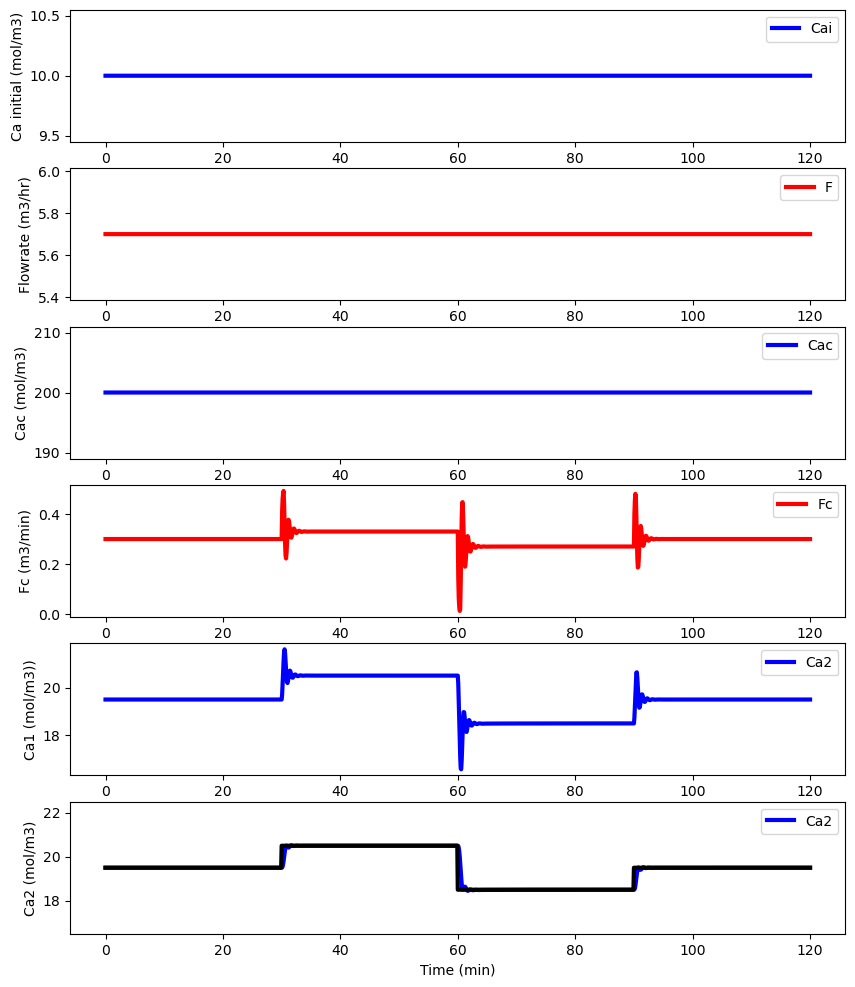

total error first doublet: 26.057626339434567
total error second doublet: 29.65882851784752
total error: 55.71645485728209


(0.2999995115799483, 19.49998110422341, 19.499978741424567)

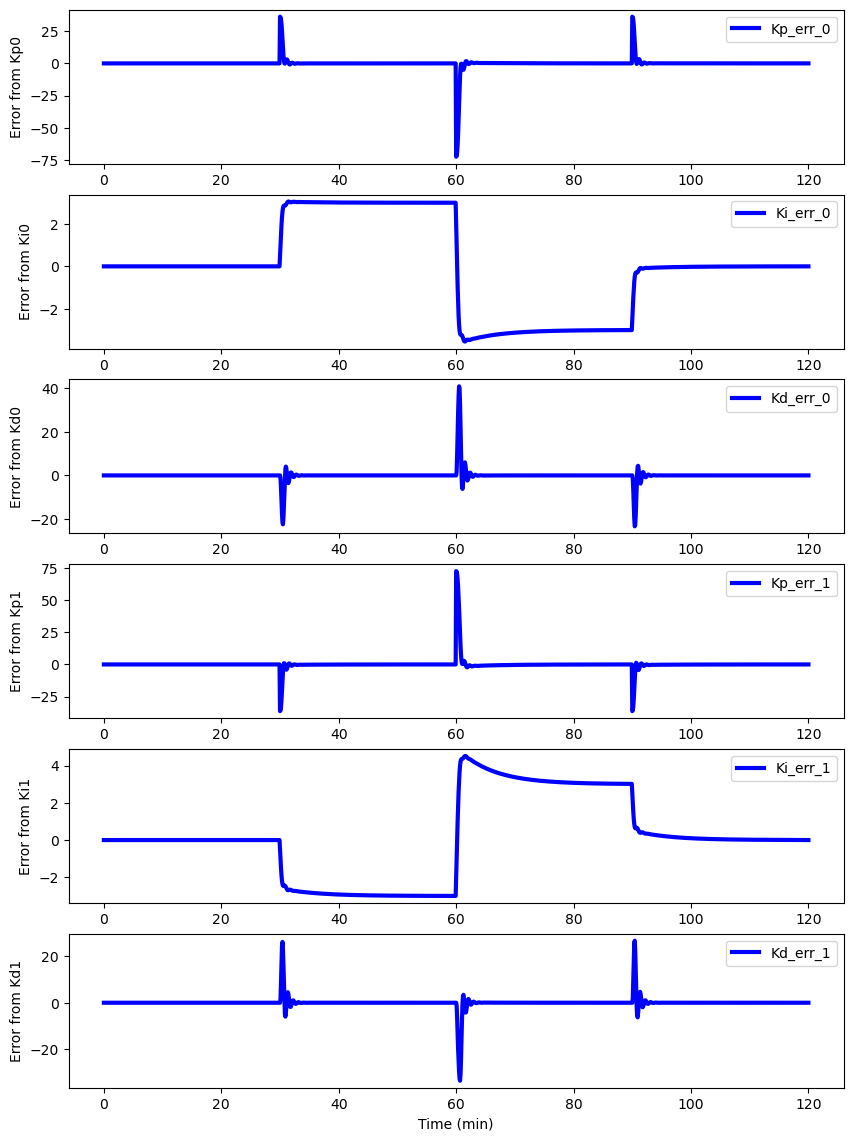

In [8]:
# With step size mathcing the data gen step size
doublet_test_exp(36.215,6.1707,10.033, 10, 5.7, 200, 0.3, [5,4])

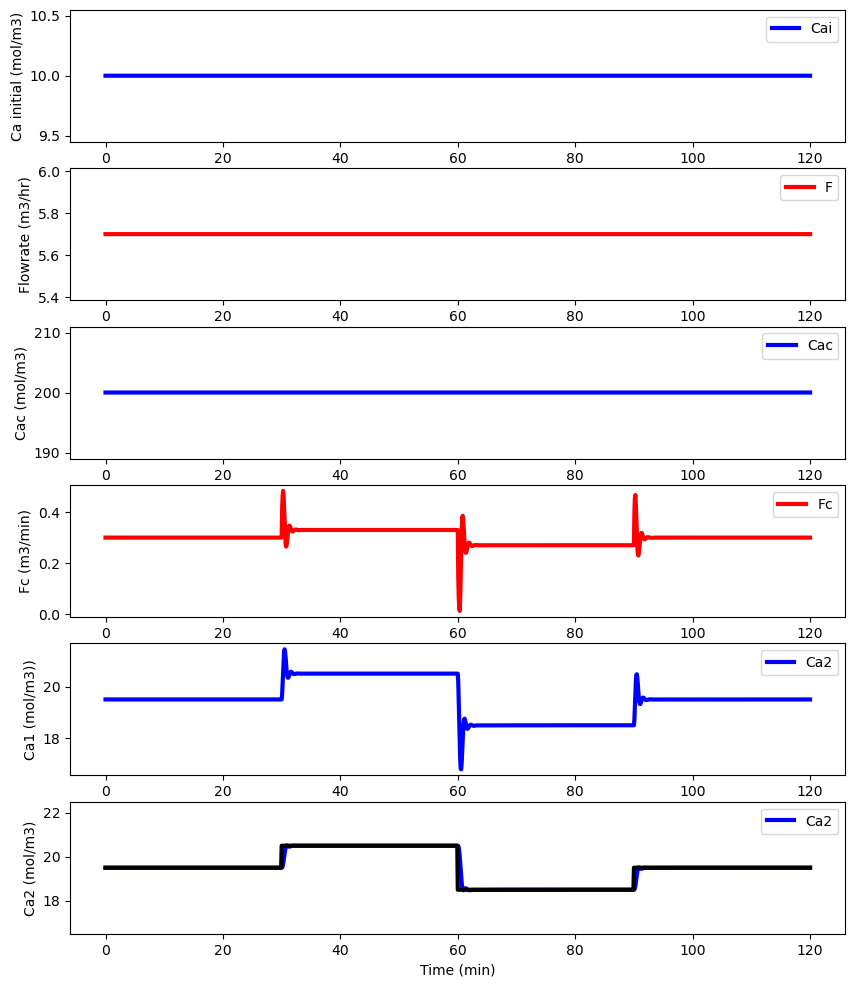

total error first doublet: 25.404137973153478
total error second doublet: 28.920975508386363
total error: 54.325113481539844


(0.2999998897908988, 19.499995440263596, 19.4999945973202)

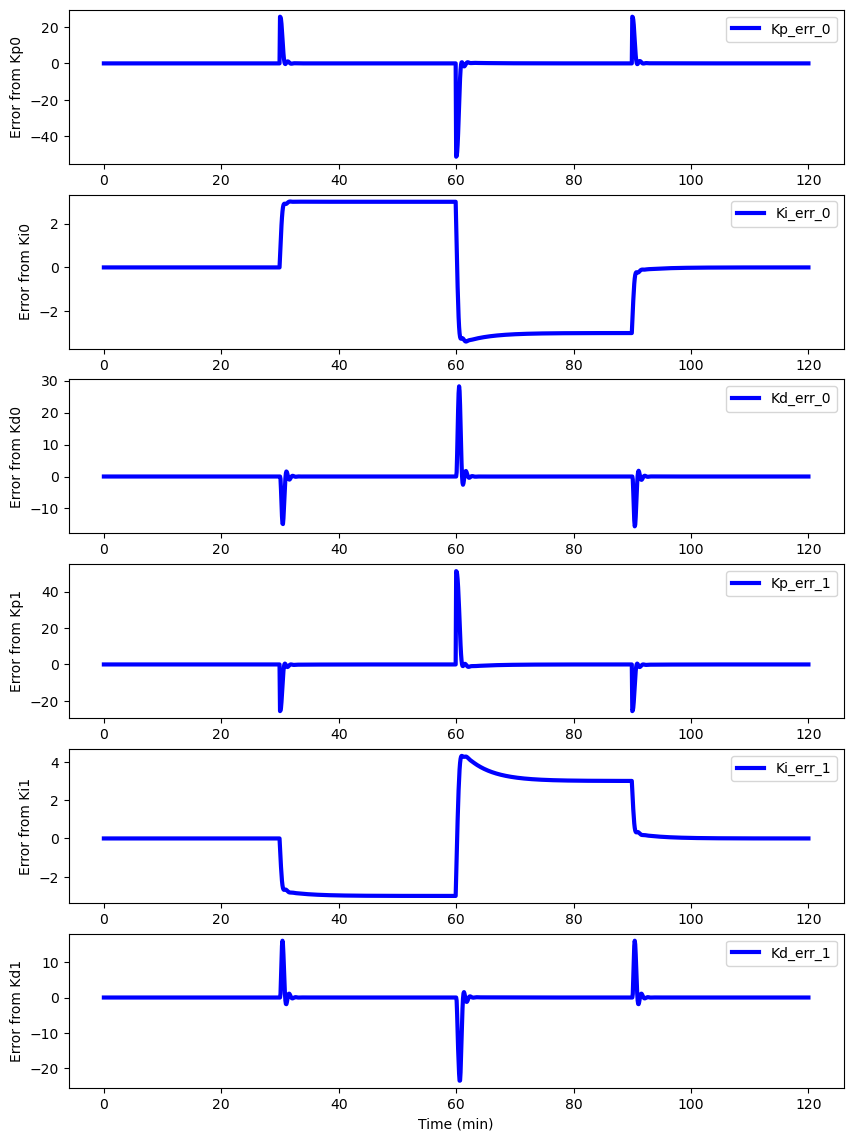

In [6]:
# With step size mathcing the data gen step size
doublet_test_exp(25.592, 6.1036, 7.2811, 10, 5.7, 200, 0.3, [5,4])

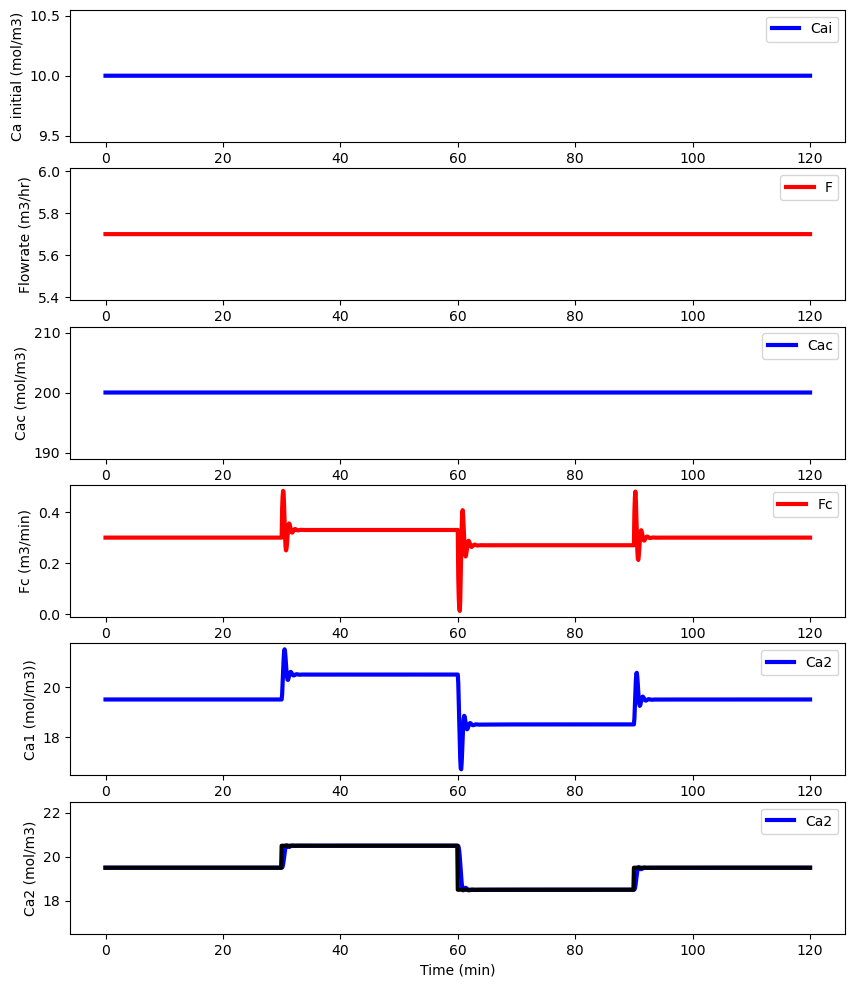

total error first doublet: 25.497935208182987
total error second doublet: 29.12823916184243
total error: 54.62617437002542


(0.2999995480609673, 19.499981907978817, 19.499979099715826)

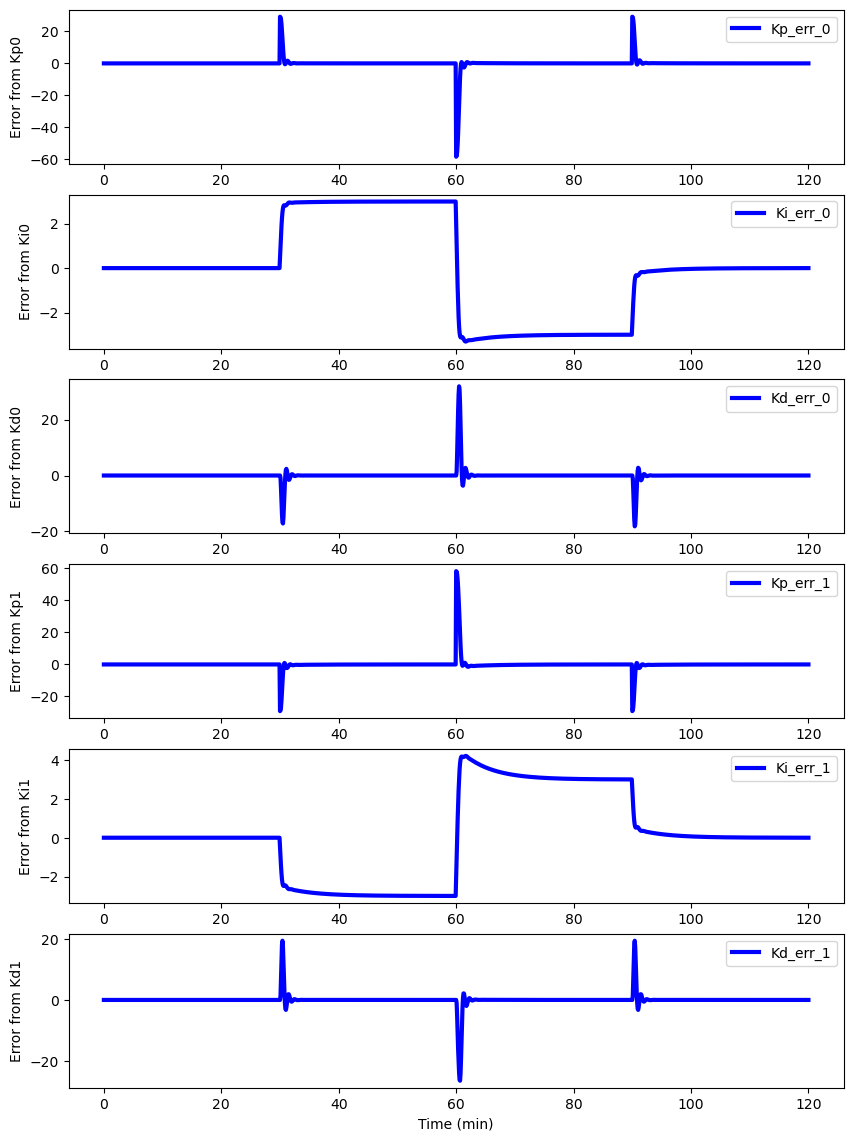

In [7]:
# With step size mathcing the data gen step size
doublet_test_exp(29.164, 6.0182, 8.0568, 10, 5.7, 200, 0.3, [5,4])

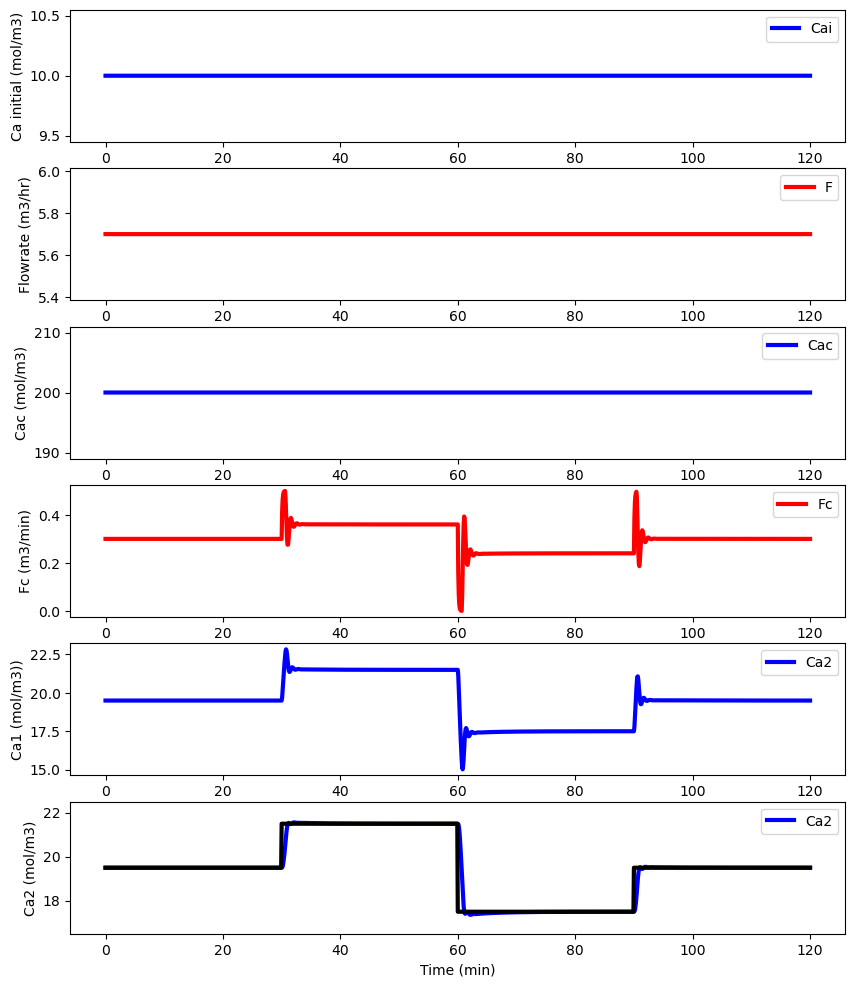

(0.30000208802104694, 19.50008358764884, 19.500096562213727)

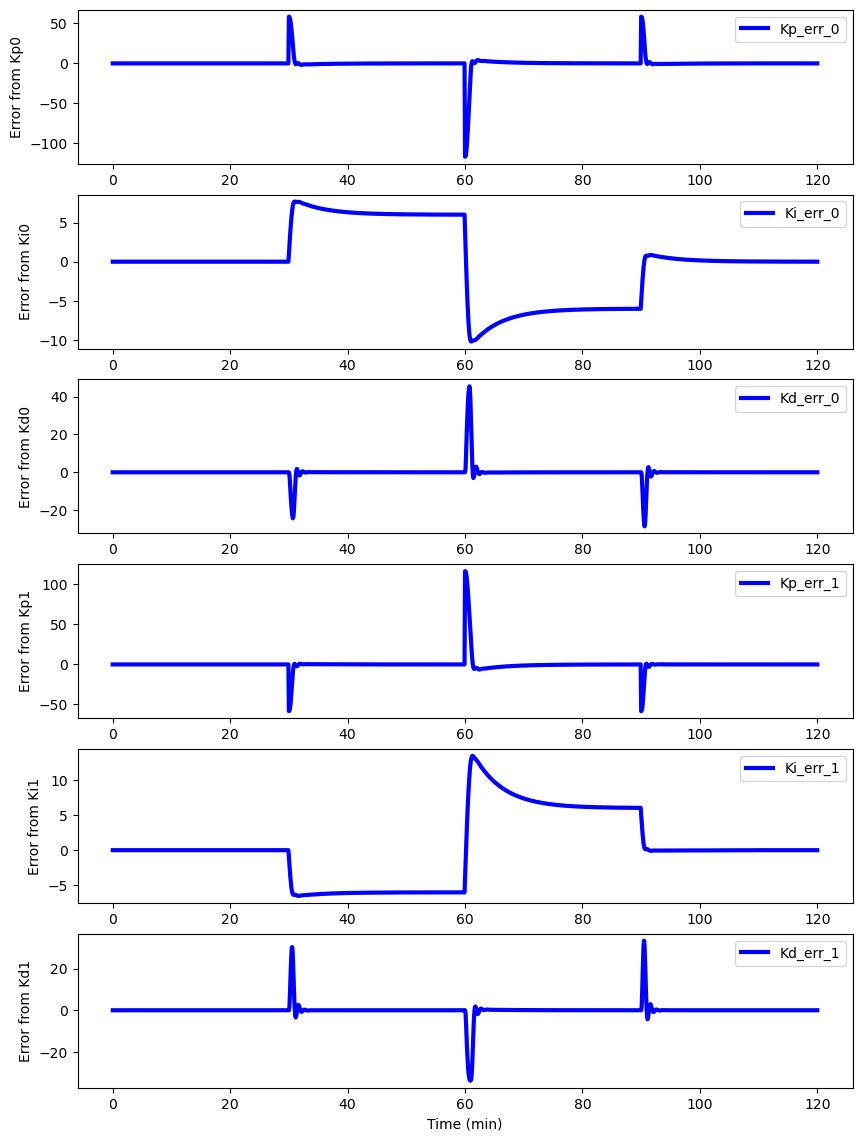

In [2]:
# With twice the step size
doublet_test_exp(29.164, 6.0182, 8.0568, 10, 5.7, 200, 0.3, [5,4])